# Building an N-Gram Language Model for Ewe
**What we'll build:** A program that learns the patterns of the Ewe language from real text and can then:
1. Tell us how "natural" a sentence sounds in Ewe
2. Generate new Ewe text


## Background: The Ewe Language

**Ewe** (pronounced *EH-weh*) is a language spoken by about 7 million people, mainly in:
- Ghana (Volta Region)
- Togo
- Benin

Ewe has some sounds that don't exist in English, which is why you'll see special characters in the text:

| Character | Sounds like |
|-----------|-------------|
| **ɔ** | open "o" (like in "off") |
| **ɛ** | open "e" (like in "bed") |
| **ŋ** | "ng" sound (like in "sing") |
| **ɖ** | retroflex "d" |
| **ƒ** | bilabial "f" |

**Why is Ewe "low-resource"?**  
Most AI language tools (like ChatGPT) are trained on billions of words from the internet. Ewe has very little text online, so we call it a **low-resource language**.

## What is an N-Gram Language Model?

### The Core Idea: Predicting the Next Word

A **language model** answers one question: *"How likely is this sequence of words?"*

An **n-gram** is just a sequence of **n** words in a row.

**Example from Ewe:**
```
Sentence: "Ne nyɔnu aɖe le evi dzim"

1-grams (unigrams):  ["Ne"], ["nyɔnu"], ["aɖe"], ["le"], ["evi"], ["dzim"]
2-grams (bigrams):   ["Ne nyɔnu"], ["nyɔnu aɖe"], ["aɖe le"], ["le evi"], ["evi dzim"]
3-grams (trigrams):  ["Ne nyɔnu aɖe"], ["nyɔnu aɖe le"], ["aɖe le evi"], ["le evi dzim"]
```

### How the model works:

The model reads a lot of Ewe text and **counts** how often words appear together. Then when predicting the next word, it picks the one that appeared most often in that context.

**Analogy:** Imagine you read 1000 Ewe books. After seeing the word "le" thousands of times, you start to notice which words usually follow it. That pattern knowledge IS the n-gram model.

### Bigram probability formula:
$$P(word_2 \mid word_1) = \frac{Count(word_1, word_2)}{Count(word_1)}$$

**In plain English:** "Out of all the times `word_1` appeared, what fraction of the time was it followed by `word_2`?"

---
## Part 1: Setup

First, let's import the Python libraries we need. 

In [1]:
# Standard Python libraries — no installation needed
import re                          # For cleaning text (regex)
import json                        # For parsing API responses
import math                        # For logarithm calculations
import random                      # For random sampling during text generation
from collections import Counter, defaultdict  # For counting n-grams efficiently

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Make plots look nicer
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# openpyxl is required for pd.read_excel — install if missing
try:
    import openpyxl
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


---
## Part 2: Load & Explore the Dataset

In [2]:
# Load the CSV file
# index_col=0 tells pandas the first column is just row numbers, not real data
df = pd.read_csv('data/EWE_ENGLISH.csv', index_col=0)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print()
df.head(5)

Dataset shape: 28614 rows × 2 columns
Columns: ['EWE', 'ENGLISH']



,EWE,ENGLISH
0,Ne nyɔnu aɖe le evi dzim eye wo le kukum nɛ la...,﻿If a woman often loss his baby after he is bo...
1,Ŋkɔ sia nye na ŋkɔ si ke ame bubu tsɔna na ɖev...,"This name comes from another person, which mea..."
2,Ame si hɔ ɖevi la ƒlela tsona ƒome bubu me alo...,This person must not be part of the whole fami...
3,Kɔnua wo yina ale: evinɔ si ga dzi ɖevi bubu a...,The ceremony is done as follow: the family of ...
4,Ne ame aɖe vayina to afimagodzi he kɔ ɖevia la...,When somebody passes through the road and find...


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows where the Ewe text is missing
df = df.dropna(subset=['EWE'])
print(f"\nRows after dropping missing Ewe text: {len(df)}")

Missing values per column:
EWE        0
ENGLISH    0
dtype: int64

Rows after dropping missing Ewe text: 28614


In [4]:
# Load additional Ewe transcriptions from the Waxal image-captioning dataset
# (University of Ghana, 2023 — 19,151 Ewe image captions, no English translation)
_XLSX_PATH = 'data/waxal_transcriptions.xlsx'

try:
    _xlsx_df = pd.read_excel(_XLSX_PATH, usecols=['Transcription'])

    # Strip leading/trailing whitespace and non-breaking spaces (\xa0)
    _transcriptions = (
        _xlsx_df['Transcription']
        .dropna()
        .str.strip()           # removes regular whitespace
        .str.strip('\xa0')     # removes non-breaking spaces
        .loc[lambda s: s.str.len() > 0]  # drop any now-empty strings
        .reset_index(drop=True)
    )

    _xlsx_rows = pd.DataFrame({'EWE': _transcriptions, 'ENGLISH': None})
    df = pd.concat([df, _xlsx_rows], ignore_index=True)

    print(f"Added {len(_transcriptions):,} transcriptions from Waxal image-captioning dataset")
    print(f"Total rows after merge: {len(df):,}")
    print(f"Sample transcription: {_transcriptions[0][:80]}")

except FileNotFoundError:
    print(f"Warning: '{_XLSX_PATH}' not found — continuing without this dataset.")
except Exception as _e:
    print(f"Warning: Excel load failed ({_e}) — continuing without this dataset.")


Added 19,151 transcriptions from Waxal image-captioning dataset
Total rows after merge: 47,765
Sample transcription: Eʋumidzraƒe le mɔ to. Ame aɖewo tɔ ɖe emɔ to. Nyɔnu eve kple ɖevi ame etɔ wole b


In [5]:
# Let's look at a few Ewe sentences up close
print("=" * 60)
print("SAMPLE EWE SENTENCES")
print("=" * 60)

for i, row in df.head(4).iterrows():
    print(f"\n[Row {i}]")
    print(f"  EWE:     {row['EWE'].strip()}")
    print(f"  ENGLISH: {row['ENGLISH'].strip()}")

SAMPLE EWE SENTENCES

[Row 0]
  EWE:     Ne nyɔnu aɖe le evi dzim eye wo le kukum nɛ la, o wɔna kɔnu na ɖevi yeye si wo ga dzi la, to ŋkɔ bubu tsɔtsɔ nɛ la me, bena ɖevi yeyela me ga ku ke o.
  ENGLISH: ﻿If a woman often loss his baby after he is born, people make a kind of ceremony for the new one born, and this ceremony is about giving to the new baby another name that help the newest stay alive.

[Row 1]
  EWE:     Ŋkɔ sia nye na ŋkɔ si ke ame bubu tsɔna na ɖevia si gɔme enye be ehɔ ɖevi la ƒle le ƒomea si.
  ENGLISH: This name comes from another person, which means that this person buys the baby from the biologic parents.

[Row 2]
  EWE:     Ame si hɔ ɖevi la ƒlela tsona ƒome bubu me alo dukɔ bubume alo edu bubume alo amedzro tso duta, vɔa nyui tɔ enye be amea ne nye amedzro tso duta.
  ENGLISH: This person must not be part of the whole family of the baby, he must be from another family, another village, another city or another region or ethnical group or another country, but the b

Ewe sentence length statistics (in words):
count    47765.0
mean        27.2
std         18.4
min          1.0
25%         16.0
50%         26.0
75%         35.0
max        416.0
Name: ewe_word_count, dtype: float64


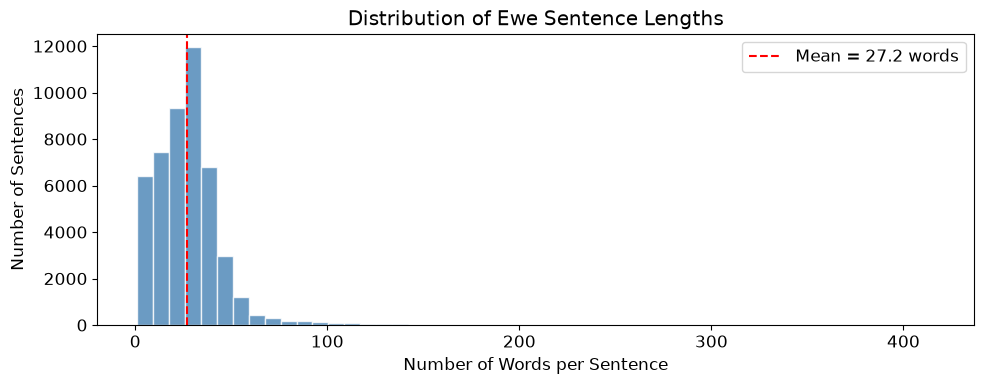

In [6]:
# Basic statistics about the dataset

# Calculate sentence lengths (number of words)
df['ewe_word_count'] = df['EWE'].apply(lambda s: len(str(s).split()))

print("Ewe sentence length statistics (in words):")
print(df['ewe_word_count'].describe().round(2))

# Plot distribution of sentence lengths
plt.figure(figsize=(10, 4))
plt.hist(df['ewe_word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Number of Words per Sentence')
plt.ylabel('Number of Sentences')
plt.title('Distribution of Ewe Sentence Lengths')
plt.axvline(df['ewe_word_count'].mean(), color='red', linestyle='--',
            label=f"Mean = {df['ewe_word_count'].mean():.1f} words")
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 3: Preprocessing the Text

Before building the model, we need to **clean** the text. Raw text has noise: punctuation, numbers, extra spaces, etc. We want the model to focus on actual Ewe words.

**Important for Ewe:** We must **keep** special characters like `ɔ, ɛ, ŋ, ɖ, ƒ` because they change word meaning. For example:
- `ko` ≠ `kɔ` (different words!)

**Punctuation:** stripping everything would mean the model never learns *where* a comma or question mark tends to go, and generated text could never punctuate itself. Stripping nothing would bury real words under noise from quotes, parentheses, etc. Middle ground: keep `. , ! ?` as their own tokens (they mark sentence type and clause boundaries — useful signal), drop everything else.

We also add special `<s>` (start) and `</s>` (end) tokens to mark sentence boundaries. This teaches the model where sentences begin and end.


In [7]:
# Special tokens that mark the start and end of a sentence
START = '<s>'   # beginning of sentence
END   = '</s>'  # end of sentence

# Punctuation we keep as its own token because it carries signal (sentence
# type, clause boundaries). Everything else (quotes, parens, dashes, ...)
# is just noise for a word-level n-gram model and gets dropped.
KEEP_PUNCT = '.,!?'

def preprocess_ewe(text):
    """
    Clean and tokenize a single Ewe sentence.
    
    Steps:
      1. Lowercase everything
      2. Isolate . , ! ? as their own tokens
      3. Remove all other punctuation (but keep Ewe special characters)
      4. Remove extra whitespace
      5. Split into a list of words
      6. Wrap with <s> and </s> tokens
    """
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Pad . , ! ? with spaces so they split out as standalone tokens
    # instead of sticking to the word before them (e.g. "la," -> "la ,")
    text = re.sub(r"([.,!?])", r" \1 ", text)
    
    # Step 3: Remove everything else that isn't a letter/digit, whitespace,
    # or one of the punctuation marks we just isolated.
    # \w matches letters and digits; \s matches spaces.
    # This regex KEEPS Ewe special characters (ɔ, ɛ, ŋ, ɖ, ƒ, etc.) because
    # Python's \w is Unicode-aware and includes accented/extended letters.
    text = re.sub(r"[^\w\s.,!?]", " ", text)
    
    # Step 4: Remove digits (numbers don't help the language model)
    text = re.sub(r"\d+", "", text)
    
    # Step 5: Collapse multiple spaces into one
    text = re.sub(r"\s+", " ", text).strip()
    
    # Step 6: Split into words
    tokens = text.split()
    
    # Step 7: Skip empty sentences
    if not tokens:
        return []
    
    # Step 8: Add sentence boundary tokens
    return [START] + tokens + [END]


# Test our function on a real Ewe sentence
sample = "Ne nyɔnu aɖe le evi dzim eye wo le kukum nɛ la,"
result = preprocess_ewe(sample)
print("Original:  ", sample)
print("Processed: ", result)


Original:   Ne nyɔnu aɖe le evi dzim eye wo le kukum nɛ la,
Processed:  ['<s>', 'ne', 'nyɔnu', 'aɖe', 'le', 'evi', 'dzim', 'eye', 'wo', 'le', 'kukum', 'nɛ', 'la', ',', '</s>']


In [8]:
# Apply preprocessing to the entire dataset
all_sentences = []

for text in df['EWE']:
    tokens = preprocess_ewe(str(text))
    if tokens:  # only keep non-empty results
        all_sentences.append(tokens)

# Flatten all tokens into one big list (useful for some calculations)
all_tokens = [token for sentence in all_sentences for token in sentence]

print(f"Total sentences:      {len(all_sentences):,}")
print(f"Total tokens:         {len(all_tokens):,}")
print(f"Unique words (vocab): {len(set(all_tokens)):,}")
print()
print("First processed sentence:", all_sentences[0])

Total sentences:      47,131
Total tokens:         1,527,719
Unique words (vocab): 42,262

First processed sentence: ['<s>', 'ne', 'nyɔnu', 'aɖe', 'le', 'evi', 'dzim', 'eye', 'wo', 'le', 'kukum', 'nɛ', 'la', ',', 'o', 'wɔna', 'kɔnu', 'na', 'ɖevi', 'yeye', 'si', 'wo', 'ga', 'dzi', 'la', ',', 'to', 'ŋkɔ', 'bubu', 'tsɔtsɔ', 'nɛ', 'la', 'me', ',', 'bena', 'ɖevi', 'yeyela', 'me', 'ga', 'ku', 'ke', 'o', '.', '</s>']


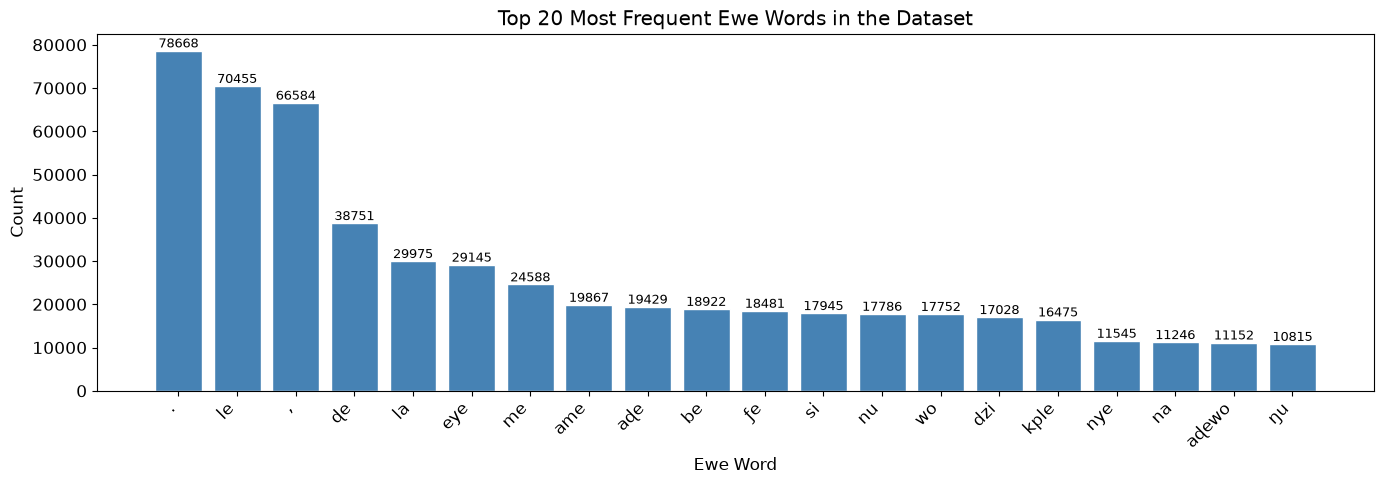


Vocabulary size (unique words): 42,260
Words appearing only once (hapax legomena): 21,794


In [9]:
# Visualize the most common Ewe words
# Exclude our artificial tokens (<s> and </s>) for a cleaner view
real_tokens = [t for t in all_tokens if t not in (START, END)]
word_freq = Counter(real_tokens)

top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(14, 5))
bars = plt.bar(words, counts, color='steelblue', edgecolor='white')
plt.xlabel('Ewe Word')
plt.ylabel('Count')
plt.title('Top 20 Most Frequent Ewe Words in the Dataset')
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nVocabulary size (unique words): {len(word_freq):,}")
print(f"Words appearing only once (hapax legomena): {sum(1 for c in word_freq.values() if c == 1):,}")

---
## Part 4: Train / Dev / Test Split

We **split** our data into three parts:
- **Training set (80%)**: The model learns its counts from this data
- **Dev set (10%)**: Used only to *tune* hyperparameters (smoothing `k`, interpolation weights) — never to train counts
- **Test set (10%)**: Touched exactly once, at the very end, to report an unbiased final perplexity

Tuning hyperparameters against the test set would leak information — the model would look better than it actually generalizes. The dev set exists so tuning has its own sandbox.


In [10]:
# Shuffle sentences randomly before splitting
# (so train/dev/test aren't from different topics)
random.seed(42)  # Setting seed makes results reproducible
shuffled = all_sentences.copy()
random.shuffle(shuffled)

# 80% train, 10% dev, 10% test
n = len(shuffled)
train_end = int(0.8 * n)
dev_end   = int(0.9 * n)

train_sentences = shuffled[:train_end]
dev_sentences   = shuffled[train_end:dev_end]
test_sentences  = shuffled[dev_end:]

print(f"Training sentences: {len(train_sentences):,}")
print(f"Dev sentences:      {len(dev_sentences):,}")
print(f"Test sentences:     {len(test_sentences):,}")


Training sentences: 37,704
Dev sentences:      4,713
Test sentences:     4,714


---
## Part 5: Building the N-Gram Models

We'll build **five** models, from no memory at all up to remembering the
last four words, and compare them:

| Model | Looks at | Memory |
|-------|----------|--------|
| **Unigram** | Each word alone | None — ignores history |
| **Bigram** | Word + 1 previous word | Short memory |
| **Trigram** | Word + 2 previous words | Medium memory |
| **4-gram** | Word + 3 previous words | Longer memory |
| **5-gram** | Word + 4 previous words | Longest memory |

### 🧮 The math

All of these are the same formula at different orders — the probability of
a word given the **n-1** words before it:

$$P(w_n \mid w_1, \ldots, w_{n-1}) = \frac{Count(w_1, \ldots, w_n)}{Count(w_1, \ldots, w_{n-1})}$$

**Unigram** (n=1) is the special case with no context at all:
$P(w) = \frac{Count(w)}{Total\ words}$

More context should mean better predictions — *if* there's enough data to
estimate it from. With a low-resource language, that's the catch: a 5-gram
context is very rarely repeated, so most 5-gram counts will be 0 or 1. That's
exactly the sparsity problem Part 6/7.5 exist to handle.


In [11]:
def extract_ngrams(sentences, n):
    """
    Extract all n-grams from a list of tokenized sentences.
    
    Example (n=2, bigrams):
      ["<s>", "le", "ame", "</s>"]  →  [('<s>','le'), ('le','ame'), ('ame','</s>')]
    """
    ngrams = []
    for sentence in sentences:
        # zip() pairs up consecutive tokens at distance n
        # zip(*[sentence[i:] for i in range(n)]) is a neat trick:
        #   for n=2: zip(sentence[0:], sentence[1:]) → bigrams
        #   for n=3: zip(sentence[0:], sentence[1:], sentence[2:]) → trigrams
        for gram in zip(*[sentence[i:] for i in range(n)]):
            ngrams.append(gram)
    return ngrams


# Let's test this on a small example first
demo_sentence = ["<s>", "le", "ame", "tɔ", "</s>"]
print("Sentence:", demo_sentence)
print("Bigrams: ", list(zip(*[demo_sentence[i:] for i in range(2)])))
print("Trigrams:", list(zip(*[demo_sentence[i:] for i in range(3)])))

Sentence: ['<s>', 'le', 'ame', 'tɔ', '</s>']
Bigrams:  [('<s>', 'le'), ('le', 'ame'), ('ame', 'tɔ'), ('tɔ', '</s>')]
Trigrams: [('<s>', 'le', 'ame'), ('le', 'ame', 'tɔ'), ('ame', 'tɔ', '</s>')]


In [12]:
# Extract and count all n-grams from training data

MAX_N = 5
MODEL_ORDER = {'unigram': 1, 'bigram': 2, 'trigram': 3, '4-gram': 4, '5-gram': 5}
ORDER_TO_MODEL = {v: k for k, v in MODEL_ORDER.items()}

print("Counting n-grams from training data...")

ngram_counts = {1: Counter(token for sentence in train_sentences for token in sentence)}
for n in range(2, MAX_N + 1):
    ngram_counts[n] = Counter(extract_ngrams(train_sentences, n))

# Total tokens (needed for unigram probabilities)
total_tokens = sum(ngram_counts[1].values())

for n in range(1, MAX_N + 1):
    print(f"Unique {n}-grams: {len(ngram_counts[n]):,}")
print(f"Total tokens:  {total_tokens:,}")

# Index each order by its (n-1)-word context so we can look up "what
# follows this context" in O(1) instead of scanning every n-gram (up to
# hundreds of thousands of entries) on every step of text generation.
context_index = {}
for n in range(2, MAX_N + 1):
    idx = defaultdict(list)
    for gram in ngram_counts[n]:
        idx[gram[:-1]].append(gram[-1])
    context_index[n] = idx


Counting n-grams from training data...


Unique 1-grams: 37,424
Unique 2-grams: 277,927
Unique 3-grams: 646,236
Unique 4-grams: 886,832
Unique 5-grams: 979,032
Total tokens:  1,222,771


---
## Part 6: The Smoothing Problem

### The Zero Probability Problem

Imagine the training data never contains the bigram `("aɖe", "tɔ")`. The raw probability would be:

$$P("tɔ" \mid "aɖe") = \frac{0}{Count("aɖe")} = 0$$

If this n-gram appears in the test set, the model gives it probability **0** — which is clearly wrong, and it gets *worse* as n grows: a specific 5-word context is much rarer than a specific 2-word one, so most 4-gram/5-gram contexts in test data were never seen in training at all.

### Fix: Add-k Smoothing (for the unigram floor)

We add a small constant **k** to every unigram count:

$$P_{smooth}(w) = \frac{Count(w) + k}{Total\ words + k \cdot |V|}$$

Where **|V|** is the vocabulary size. With most higher-order *contexts* seen only once or twice across ~40k training sentences, applying this same `+ k·|V|` trick directly to a 3/4/5-gram denominator would dwarf the real counts and crush every probability toward zero — worse the higher n goes. So add-k is used only for the unigram distribution below.

### Fix: Recursive Interpolation (for bigram through 5-gram)

Each order instead **backs off** to the order below it:

$$P_n(w_n \mid w_1..w_{n-1}) = \lambda_n \cdot P_{MLE}(w_n \mid w_1..w_{n-1}) + (1-\lambda_n) \cdot P_{n-1}(w_n \mid w_2..w_{n-1})$$

One weight `λ_n` per order (n=2..5), each mixing that order's raw estimate with the (already-smoothed) estimate one order down — which itself backs off further, all the way to the add-k unigram floor. This is what makes a sparse 5-gram context still usable: if it was never seen, `λ_5` contributes nothing and the whole thing falls through to the 4-gram estimate, and so on down.

Rather than guess the weights here, Part 7.5 tunes `k` and every `λ_n` by grid search on a held-out dev set — the values set below are just a reasonable starting point.


In [13]:
# Build the vocabulary from training data
# <UNK> is never seen in training (count 0), so it always falls back to the
# add-k smoothed unigram floor — exactly right for a truly unseen word.
vocabulary = set(ngram_counts[1].keys()) | {'<UNK>'}
vocab_size  = len(vocabulary)

print(f"Vocabulary size (|V|): {vocab_size:,}")

# Add-k smoothing is only used at the unigram level, where the context
# (total_tokens) is huge enough that k*|V| doesn't swamp real counts.
SMOOTH_K = 0.1

# One interpolation weight per order n=2..MAX_N: how much to trust that
# order's raw MLE estimate vs. backing off entirely to the (n-1)-gram
# estimate. Starting points below; Part 7.5 tunes these on dev data.
LAMBDA = {2: 0.75, 3: 0.7, 4: 0.7, 5: 0.7}


def _known(word):
    """Map any word outside the training vocabulary to <UNK>."""
    return word if word in vocabulary else '<UNK>'


def unigram_prob(word, smoothing=True):
    """
    P(word) = count(word) / total_tokens
    With smoothing: (count + k) / (total_tokens + k * vocab_size)
    """
    count = ngram_counts[1].get(_known(word), 0)
    if smoothing:
        return (count + SMOOTH_K) / (total_tokens + SMOOTH_K * vocab_size)
    else:
        return count / total_tokens if total_tokens > 0 else 0


def ngram_prob(context, word, n, smoothing=True):
    """
    P(word | context) for an n-gram, where context is a tuple of n-1 words.

    Recursive interpolation: blend the order-n MLE estimate with the
    (n-1)-gram estimate (which itself keeps backing off), so a sparse
    high-order context still falls back gracefully instead of collapsing
    to zero. n=1 is the base case: the smoothed unigram distribution.
    """
    if n == 1:
        return unigram_prob(word, smoothing)

    context = tuple(_known(w) for w in context)
    word = _known(word)
    # ngram_counts[1] (unigrams) is keyed by bare word strings, not 1-tuples
    # like every other order, so the n=2 case needs one line to unwrap it.
    if n - 1 == 1:
        context_count = ngram_counts[1].get(context[0], 0)
    else:
        context_count = ngram_counts[n - 1].get(context, 0)
    mle = ngram_counts[n].get(context + (word,), 0) / context_count if context_count > 0 else 0
    if not smoothing:
        return mle
    lam = LAMBDA[n]
    return lam * mle + (1 - lam) * ngram_prob(context[1:], word, n - 1, smoothing)


# Thin convenience wrappers matching the earlier bigram_prob/trigram_prob API
def bigram_prob(w1, w2, smoothing=True):
    return ngram_prob((w1,), w2, 2, smoothing)


def trigram_prob(w1, w2, w3, smoothing=True):
    return ngram_prob((w1, w2), w3, 3, smoothing)


# --- Quick sanity check ---
print()
print("Quick probability checks:")
print(f"  P('le')                        = {unigram_prob('le'):.6f}")
print(f"  P('ame' | 'le')                = {ngram_prob(('le',), 'ame', 2):.6f}")
print(f"  P('tɔ' | 'le','ame')           = {ngram_prob(('le', 'ame'), 'tɔ', 3):.6f}")


Vocabulary size (|V|): 37,425

Quick probability checks:
  P('le')                        = 0.045727
  P('ame' | 'le')                = 0.008732
  P('tɔ' | 'le','ame')           = 0.000254


---
## Part 7: Scoring Sentences

We can now score any Ewe sentence — telling us how "natural" it sounds according to the model.

### Using Log Probabilities

The probability of a full sentence is the product of each word's probability:

$$P(sentence) = P(w_1) \times P(w_2 \mid w_1) \times P(w_3 \mid w_1, w_2) \times \ldots$$

Multiplying many small numbers together causes them to become **incredibly tiny** (computers can lose precision). Instead, we add **logarithms**:

$$\log P(sentence) = \log P(w_1) + \log P(w_2 \mid w_1) + \ldots$$

Higher log-probability = more natural sentence.

In [14]:
def score_sentence(tokens, model='bigram'):
    """
    Compute the total log-probability of a tokenized sentence under the
    given model ('unigram' .. '5-gram').

    All models skip the <s> start token so they predict the same
    N = len(tokens)-1 positions, making scores directly comparable. Early
    positions that don't yet have n-1 words of context use whatever
    shorter context is available (e.g. the very first predicted word only
    ever has <s> as context, so even a 5-gram model scores it as a
    bigram) — ngram_prob's recursive interpolation handles this the same
    way it handles any other sparse context.

    Returns:
        float: Sum of log-probabilities (higher = more natural)
    """
    n = MODEL_ORDER[model]
    log_prob = 0.0
    for i in range(1, len(tokens)):
        ctx_len = min(n - 1, i)
        context = tuple(tokens[i - ctx_len:i])
        log_prob += math.log(ngram_prob(context, tokens[i], ctx_len + 1))
    return log_prob


# Test scoring on a few sentences.
# NOTE: sentences of different lengths have different total word counts, so raw
# log-probs aren't directly comparable. We show per-word average instead.
test_cases = [
    "Ne nyɔnu aɖe le evi dzim",    # Real Ewe (from dataset)
    "le ame tɔ",                    # Simple real Ewe
    "zzz bbb qqq",                  # Nonsense words
]

header = f"{'Sentence':<35} {'# words':>7}" + ''.join(f"{m.capitalize():>10}" for m in MODEL_ORDER)
print(header)
print("-" * len(header))

for sentence in test_cases:
    tokens = preprocess_ewe(sentence)
    n_pred = len(tokens) - 1  # predicted positions (excludes <s>)
    scores = [score_sentence(tokens, m) / n_pred for m in MODEL_ORDER]
    row = f"{sentence:<35} {n_pred:>7}" + ''.join(f"{s:>10.2f}" for s in scores)
    print(row)

print()
print("Per-word average log-prob: higher (less negative) = more natural.")
print("Real Ewe should score clearly higher than nonsense across the board.")


Sentence                            # words   Unigram    Bigram   Trigram    4-gram    5-gram
---------------------------------------------------------------------------------------------
Ne nyɔnu aɖe le evi dzim                  7     -5.95     -4.55     -4.05     -3.64     -2.87
le ame tɔ                                 4     -4.25     -4.99     -5.61     -6.21     -6.51
zzz bbb qqq                               4    -13.11    -14.50    -15.40    -16.00    -16.30

Per-word average log-prob: higher (less negative) = more natural.
Real Ewe should score clearly higher than nonsense across the board.


---
## Part 7.5: Hyperparameter Tuning (Dev Set)

`SMOOTH_K` and every `LAMBDA[n]` above were picked by hand. The standard
way to choose them properly is a small **grid search that minimizes
perplexity on the dev set** — never the test set, since tuning against
test data would make the final number optimistic instead of honest.

The search is staged, tuning lower orders first so each later stage's
backoff target is already tuned (a full joint grid over `k` and four
lambdas would be enormous for little extra benefit):
1. Sweep `k` → keep the value minimizing **unigram** dev perplexity. Every
   order eventually backs off to this smoothed unigram floor.
2. For n = 2, 3, 4, 5 in order: with everything below n already tuned,
   sweep `LAMBDA[n]` → keep the value minimizing that **order's** dev
   perplexity.

The test set stays untouched until the final evaluation in Part 8.


In [15]:
def compute_perplexity(sentences, model='bigram'):
    """
    Compute perplexity of a model on a list of sentences.

    N = total predicted tokens (len(tokens)-1 per sentence, excluding <s>),
    matching exactly what score_sentence sums for all models.

    Lower perplexity = better model.
    """
    total_log_prob = 0.0
    total_words    = 0

    for tokens in sentences:
        if len(tokens) < 2:
            continue  # skip very short sentences

        total_log_prob += score_sentence(tokens, model)
        total_words    += len(tokens) - 1  # exclude <s>; matches score_sentence

    avg_log_prob = total_log_prob / total_words
    return math.exp(-avg_log_prob)


print("Tuning hyperparameters on DEV set...")
print()

# --- Stage 1: smoothing constant k, scored via unigram dev perplexity ---
best_k, best_k_pp = SMOOTH_K, float('inf')
for k in [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]:
    SMOOTH_K = k
    pp = compute_perplexity(dev_sentences, 'unigram')
    if pp < best_k_pp:
        best_k, best_k_pp = k, pp
SMOOTH_K = best_k
print(f"Best k              = {SMOOTH_K:<5} (unigram dev perplexity = {best_k_pp:,.1f})")

# --- Stages 2..MAX_N: one interpolation weight per order, tuned in
# increasing order so each stage's lower-order backoff is already tuned ---
for n in range(2, MAX_N + 1):
    model_name = ORDER_TO_MODEL[n]
    best_lam, best_lam_pp = LAMBDA[n], float('inf')
    for lam in [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]:
        LAMBDA[n] = lam
        pp = compute_perplexity(dev_sentences, model_name)
        if pp < best_lam_pp:
            best_lam, best_lam_pp = lam, pp
    LAMBDA[n] = best_lam
    print(f"Best LAMBDA[{n}] ({model_name:<7}) = {LAMBDA[n]:<5} (dev perplexity = {best_lam_pp:,.1f})")

print()
print("Tuned hyperparameters now in use for the rest of the notebook:")
print(f"  SMOOTH_K = {SMOOTH_K}")
print(f"  LAMBDA   = {LAMBDA}")


Tuning hyperparameters on DEV set...



Best k              = 1.0   (unigram dev perplexity = 588.9)


Best LAMBDA[2] (bigram ) = 0.75  (dev perplexity = 167.6)


Best LAMBDA[3] (trigram) = 0.5   (dev perplexity = 140.9)


Best LAMBDA[4] (4-gram ) = 0.5   (dev perplexity = 188.4)


Best LAMBDA[5] (5-gram ) = 0.5   (dev perplexity = 307.2)

Tuned hyperparameters now in use for the rest of the notebook:
  SMOOTH_K = 1.0
  LAMBDA   = {2: 0.75, 3: 0.5, 4: 0.5, 5: 0.5}


---
## Part 8: Evaluating with Perplexity

### What is Perplexity?

**Perplexity** measures how "surprised" or "confused" the model is by new text.

- **Low perplexity** = model is confident, language looks familiar → **good model**
- **High perplexity** = model is confused, many unexpected words → **poor model**

Think of it like this: if you know English well, and someone gives you an English sentence, you're not surprised (low perplexity). But if they give you random letters, you're very confused (high perplexity).

### Formula:

$$PP = e^{-\frac{1}{N}\sum_{i=1}^{N}\log P(w_i)}$$

Where **N** is the total number of words in the test set.

In [16]:
print("Computing perplexity on TEST set (hyperparameters were tuned on DEV set above — test set untouched until now)...")
print()

results = {}
for model in MODEL_ORDER:
    pp = compute_perplexity(test_sentences, model)
    results[model] = pp
    print(f"  {model.capitalize()} Perplexity: {pp:,.1f}")

print()
best_model = min(results, key=results.get)
print(f"Best model: {best_model.upper()} (lowest perplexity = {results[best_model]:,.1f})")


Computing perplexity on TEST set (hyperparameters were tuned on DEV set above — test set untouched until now)...

  Unigram Perplexity: 595.9


  Bigram Perplexity: 167.3


  Trigram Perplexity: 139.2


  4-gram Perplexity: 184.6


  5-gram Perplexity: 299.6

Best model: TRIGRAM (lowest perplexity = 139.2)


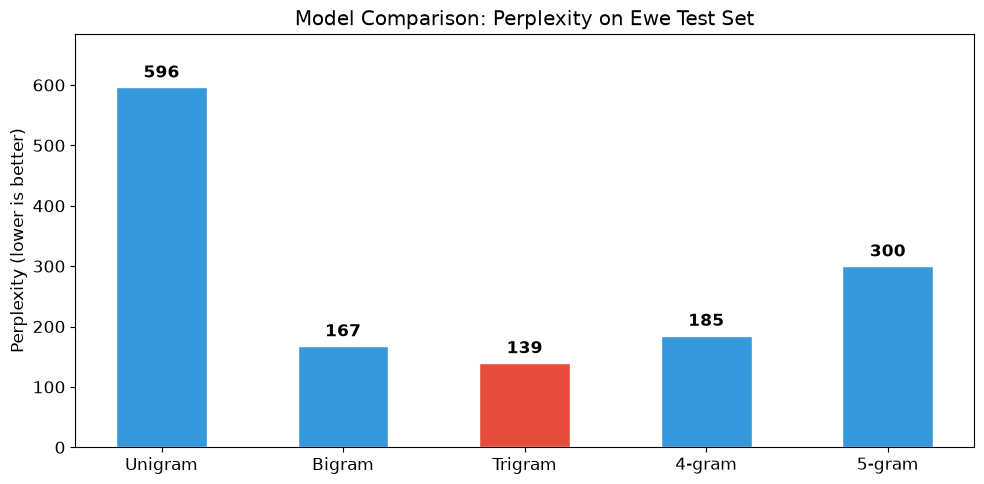


Interpretation: The trigram model is 4.3x less confused than the unigram model on unseen Ewe text.


In [17]:
# Visualize perplexity comparison
models = list(results.keys())
perplexities = list(results.values())
colors = ['#e74c3c' if m == best_model else '#3498db' for m in models]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([m.capitalize() for m in models], perplexities, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, perplexities):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Perplexity (lower is better)')
ax.set_title('Model Comparison: Perplexity on Ewe Test Set')
ax.set_ylim(0, max(perplexities) * 1.15)
plt.tight_layout()
plt.show()

print(f"\nInterpretation: The {best_model} model is {results['unigram']/results[best_model]:.1f}x" 
      f" less confused than the unigram model on unseen Ewe text.")

---
## Part 9: Generating Ewe Text

Now for the most exciting part — we can use our model to **generate new Ewe sentences**!

### How generation works:
1. Start with `<s>` (beginning of sentence)
2. Look at as much of the recent context as the model uses (up to the last 4 words for the 5-gram model)
3. **Sample** the next word based on probabilities (higher probability = more likely to be chosen)
4. Repeat until we generate `</s>` (end of sentence) or hit max length


In [18]:
def get_candidates(context, model='bigram', top_k=50):
    """
    Given the tokens generated so far, return the top-k candidate next
    words and their probabilities under the given model.
    """
    n = MODEL_ORDER[model]
    candidates = {}

    if n == 1:
        # most_common() ranks by frequency; Counter.keys() would instead be
        # in first-seen order, which biased generation toward whatever
        # words happened to appear early in the training data.
        for word, _ in ngram_counts[1].most_common(top_k * 10):
            candidates[word] = unigram_prob(word)
    else:
        ctx_len = min(n - 1, len(context))
        ctx = tuple(context[-ctx_len:])
        # O(1) lookup via the prebuilt index, instead of scanning every
        # n-gram (hundreds of thousands of entries) on every generated word
        for w in context_index[ctx_len + 1].get(ctx, []):
            candidates[w] = ngram_prob(ctx, w, ctx_len + 1)
        # If this exact context was never seen, fall back one order down
        if not candidates:
            return get_candidates(context, ORDER_TO_MODEL[n - 1], top_k)

    # Return top-k candidates sorted by probability
    top = sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return top


def generate_sentence(model='bigram', max_words=20, temperature=1.0, seed=None):
    """
    Generate a new Ewe sentence using the n-gram model.
    
    Parameters:
        model:       'unigram', 'bigram', 'trigram', '4-gram', or '5-gram'
        max_words:   Maximum sentence length
        temperature: Controls randomness.
                       1.0 = normal, >1.0 = more random, <1.0 = more conservative
        seed:        Random seed for reproducibility
    
    Returns:
        str: Generated Ewe sentence (without boundary tokens)
    """
    if seed is not None:
        random.seed(seed)
    
    generated = [START]
    
    for _ in range(max_words):
        # Get candidate next words
        candidates = get_candidates(generated, model)
        
        if not candidates:
            break
        
        words, probs = zip(*candidates)
        
        # Apply temperature: adjust probabilities
        # Higher temperature = more uniform distribution = more variety
        adjusted = [p ** (1 / temperature) for p in probs]
        total    = sum(adjusted)
        adjusted = [p / total for p in adjusted]  # normalize to sum to 1
        
        # Sample next word based on probabilities
        next_word = random.choices(words, weights=adjusted, k=1)[0]
        
        # Stop if we hit end-of-sentence token
        if next_word == END:
            break
        
        generated.append(next_word)
    
    # Remove the <s> start token and join words
    return ' '.join(generated[1:])


print("Generation functions ready!")


Generation functions ready!


In [19]:
# Generate sample sentences from each model
print("=" * 60)
print("GENERATED EWE SENTENCES")
print("=" * 60)

for model_name in MODEL_ORDER:
    print(f"\n{model_name.upper()} model:")
    for i in range(3):
        sentence = generate_sentence(model=model_name, max_words=12, temperature=1.0)
        print(f"  [{i+1}] {sentence}")


GENERATED EWE SENTENCES

UNIGRAM model:
  [1] ame ame aɖewo ƒe . nu ke be ne ke
  [2] . nu
  [3] be na dzi <s> asi ɖe ale ale la aɖewo le ke

BIGRAM model:
  [1] ame si wodo awu ɣie enu na ɖe edzi yim le anyigba
  [2] ame aɖewo tɔ ɖi ɖe dzi . ɖevi ɖeka hā le eŋu
  [3] gake esi la

TRIGRAM model:
  [1] exɔ exɔ gãwo ɖewo dome . nyɔnu kple ŋutsuwo tso eme la


  [2] le ŋufɔke la , eye ame aɖeke mele asinye be mahe gbegblẽ
  [3] ke ne wokpɔ dɔmavɔleameŋu aɖe le afi ma hã ava wɔ nane

4-GRAM model:
  [1] ɖe ha wo le .
  [2] ame siawoe nye bitia , farao vinyɔnu va kɔe , eye wòna
  [3] ke yudatɔ susɔe siwo le samaria kple nuto siwo me kesinɔnuwo bɔ

5-GRAM model:
  [1] eye wotsɔ nyitsu alafa ɖeka , agbo alafa eve kple alẽvi alafa
  [2] ke boŋ na wò nuwɔna kple wò moɖoɖo nana amea nanya nu
  [3] ke le nu si wotsɔ sa vɔ na trɔ wo ɖuɖu ŋu


In [20]:
# Experiment with temperature
print("=" * 60)
print("EFFECT OF TEMPERATURE on BIGRAM model")
print("=" * 60)
print()

print("Low temperature (0.5) → more predictable, repetitive:")
for i in range(3):
    print(f"  {generate_sentence('bigram', max_words=10, temperature=0.5)}")

print()
print("Normal temperature (1.0) → balanced:")
for i in range(3):
    print(f"  {generate_sentence('bigram', max_words=10, temperature=1.0)}")

print()
print("High temperature (2.0) → more diverse, sometimes weird:")
for i in range(3):
    print(f"  {generate_sentence('bigram', max_words=10, temperature=2.0)}")

EFFECT OF TEMPERATURE on BIGRAM model

Low temperature (0.5) → more predictable, repetitive:
  ame siwo le wo katã wo le anyigba , ame
  eye ame aɖewo le .
  gake menye ame aɖewo ɖe edzi .

Normal temperature (1.0) → balanced:


  nye , afi si woyɔna be le megbe . wole


  eye ame si ke ame bubuwo .
  ɖevi ɖeka eye wonɔ te ɖe ta . yevu nyɔnu

High temperature (2.0) → more diverse, sometimes weird:


  kple woƒe awu .
  ƒe akpa le atsitre ɖɔ gaŋkui ɖeka . aɖe ɖo
  be ame kae nana nu gbagbe dzie wò me ɖe


---
## Part 10: Analysis 

Let's look inside the model to understand what patterns it discovered in Ewe.

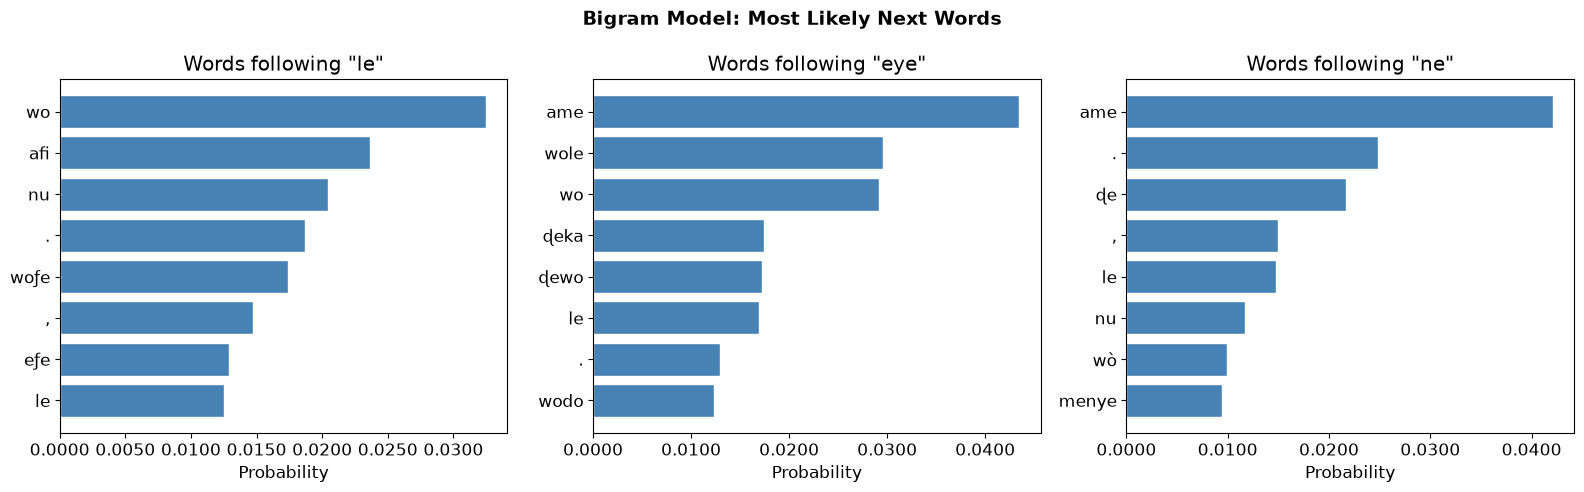

In [21]:
# What words most commonly follow specific Ewe words?

def most_likely_next(word, top_n=10):
    """Show the top N most likely words to follow a given word (bigram model)."""
    candidates = [(w2, bigram_prob(word, w2)) for w2 in context_index[2].get((word,), [])]
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[:top_n]


# Pick some common Ewe words to analyze
common_words = ['le', 'eye', 'ne']

fig, axes = plt.subplots(1, len(common_words), figsize=(16, 5))

for ax, word in zip(axes, common_words):
    next_words = most_likely_next(word, top_n=8)
    if not next_words:
        ax.set_title(f'No data for "{word}"')
        continue
    
    labels, probs = zip(*next_words)
    ax.barh(labels[::-1], probs[::-1], color='steelblue', edgecolor='white')
    ax.set_xlabel('Probability')
    ax.set_title(f'Words following "{word}"')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.suptitle('Bigram Model: Most Likely Next Words', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

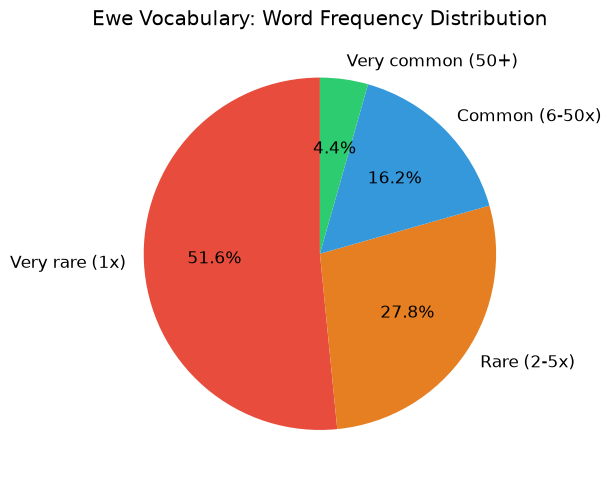

This shows why smoothing matters for low-resource languages!
Words seen only once: 21,794 (51.6% of vocab)


In [22]:
# Vocabulary coverage: how much of the vocabulary is "well-represented"?
freq_buckets = {'Very rare (1x)': 0, 'Rare (2-5x)': 0, 'Common (6-50x)': 0, 'Very common (50+)': 0}

for word, count in word_freq.items():
    if count == 1:
        freq_buckets['Very rare (1x)'] += 1
    elif count <= 5:
        freq_buckets['Rare (2-5x)'] += 1
    elif count <= 50:
        freq_buckets['Common (6-50x)'] += 1
    else:
        freq_buckets['Very common (50+)'] += 1

labels = list(freq_buckets.keys())
sizes  = list(freq_buckets.values())
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90)
ax.set_title('Ewe Vocabulary: Word Frequency Distribution')
plt.tight_layout()
plt.show()

print("This shows why smoothing matters for low-resource languages!")
print(f"Words seen only once: {freq_buckets['Very rare (1x)']:,} ({100*freq_buckets['Very rare (1x)']/len(word_freq):.1f}% of vocab)")

---
## Part 11: Interactive Demo — Score Your Own Sentence

You can type any Ewe sentence and see how the model scores it!

In [23]:
def score_and_explain(ewe_text, model='bigram'):
    """
    Score an Ewe sentence and show a word-by-word breakdown.
    """
    n = MODEL_ORDER[model]
    tokens = preprocess_ewe(ewe_text)

    print(f"Input:  {ewe_text}")
    print(f"Tokens: {tokens}")
    print()
    print(f"Word-by-word probabilities ({model} model):")
    print(f"  {'Context':<25} → {'Next word':<15} {'Log-prob':>10}")
    print("  " + "-" * 55)

    total_log = 0.0

    for i in range(1, len(tokens)):
        ctx_len = min(n - 1, i)
        context = tuple(tokens[i - ctx_len:i])
        lp = math.log(ngram_prob(context, tokens[i], ctx_len + 1))
        total_log += lp

        if ctx_len == 0:
            ctx_label = '(none)'
        elif ctx_len == 1:
            ctx_label = repr(context[0])
        else:
            ctx_label = repr(context)
        print(f"  {ctx_label:<25} → {repr(tokens[i]):<15} {lp:>10.4f}")

    print()
    print(f"Total log-probability: {total_log:.4f}")
    n_predicted = len(tokens) - 1  # exclude <s>
    print(f"Perplexity of this sentence: {math.exp(-total_log / n_predicted):.2f}")


# Try a real Ewe sentence from the dataset
score_and_explain("Ame le mia si, ame le mia, enkoe nye yesu kristo", model='bigram')


Input:  Ame le mia si, ame le mia, enkoe nye yesu kristo
Tokens: ['<s>', 'ame', 'le', 'mia', 'si', ',', 'ame', 'le', 'mia', ',', 'enkoe', 'nye', 'yesu', 'kristo', '</s>']

Word-by-word probabilities (bigram model):
  Context                   → Next word         Log-prob
  -------------------------------------------------------
  '<s>'                     → 'ame'              -2.9751
  'ame'                     → 'le'               -4.2523
  'le'                      → 'mia'              -5.9374
  'mia'                     → 'si'               -3.2956
  'si'                      → ','                -4.0554
  ','                       → 'ame'              -3.4018
  'ame'                     → 'le'               -4.2523
  'le'                      → 'mia'              -5.9374
  'mia'                     → ','                -4.3489
  ','                       → 'enkoe'           -15.4331
  'enkoe'                   → 'nye'              -6.3007
  'nye'                     → 'yesu'       

In [24]:
# Compare two sentences
print("Comparing two sentences:\n")

sentence_a = "le ame tɔ"          # try a simple Ewe phrase
sentence_b = "tɔ le ame"          # same words, different order

for s in [sentence_a, sentence_b]:
    t = preprocess_ewe(s)
    lp = score_sentence(t, 'bigram')
    print(f"  '{s}'  →  log-prob = {lp:.4f}")

print("\n(The sentence with higher log-prob sounds more natural to the model)")

Comparing two sentences:

  'le ame tɔ'  →  log-prob = -20.0204
  'tɔ le ame'  →  log-prob = -19.8016

(The sentence with higher log-prob sounds more natural to the model)


---
## Part 12: Summary & Key Takeaways

### What we built:

| Component | What it does |
|-----------|--------------|
| **Preprocessing** | Cleaned Ewe text while preserving special characters |
| **N-gram extraction** | Counted how often word sequences appear |
| **Laplace smoothing** | Fixed the zero-probability problem |
| **Perplexity** | Measured how "confused" the model is on new text |
| **Text generation** | Generated new Ewe sentences using learned patterns |

### What we learned about Ewe:
- The dataset has ~47,000 sentences of real Ewe text (~38k after the train split)
- Many Ewe words are rare (appear only once) — typical of low-resource languages
- **Trigram is the sweet spot, not 5-gram.** Perplexity drops from unigram → bigram →
  trigram, then gets *worse* at 4-gram and 5-gram (see Part 8). More context should
  help in principle, but a 4/5-word context is rarely repeated across only ~38k
  training sentences, so those higher orders mostly see 0-or-1 counts and end up
  leaning on backed-off lower-order estimates anyway, with extra noise on top. This
  is the concrete version of "n-gram models need exponentially more data as n grows."

### Why n-gram models for Ewe (not neural networks)?
- Neural models need **millions** of examples to work well
- Ewe has far less data available
- N-gram models are **interpretable** — you can see exactly what they learned
- N-gram models are **fast** and work on any computer

### Limitations & Next Steps:
- N-gram models can't understand long-range grammar dependencies
- Bigger n alone doesn't help without more data — ours peaks at trigram (see above)
- More advanced smoothing (Kneser-Ney) would give better probability estimates,
  especially at 4-gram/5-gram where sparsity hurts most
- Character-level n-grams might capture Ewe morphology better

---
**Congratulations!** You built a working language model for Ewe from scratch. 🎉

In [25]:
# Final summary printout
print("=" * 55)
print("EWE N-GRAM LANGUAGE MODEL — FINAL SUMMARY")
print("=" * 55)
print(f"  Training sentences : {len(train_sentences):,}")
print(f"  Dev sentences      : {len(dev_sentences):,}")
print(f"  Test sentences     : {len(test_sentences):,}")
print(f"  Vocabulary size    : {vocab_size:,} unique words")
for n in range(2, MAX_N + 1):
    print(f"  Unique {n}-grams     : {len(ngram_counts[n]):,}")
print()
print("  Tuned hyperparameters (dev set):")
print(f"    SMOOTH_K = {SMOOTH_K}")
print(f"    LAMBDA   = {LAMBDA}")
print()
print("  Perplexity Results (test set):")
for m, pp in results.items():
    marker = " ← best" if m == best_model else ""
    print(f"    {m.capitalize():10s}: {pp:>10,.1f}{marker}")
print()
print(f"  Sample generated Ewe ({best_model} model):")
for i in range(3):
    print(f"    {generate_sentence(best_model, max_words=10)}")
print("=" * 55)


EWE N-GRAM LANGUAGE MODEL — FINAL SUMMARY
  Training sentences : 37,704
  Dev sentences      : 4,713
  Test sentences     : 4,714
  Vocabulary size    : 37,425 unique words
  Unique 2-grams     : 277,927
  Unique 3-grams     : 646,236
  Unique 4-grams     : 886,832
  Unique 5-grams     : 979,032

  Tuned hyperparameters (dev set):
    SMOOTH_K = 1.0
    LAMBDA   = {2: 0.75, 3: 0.5, 4: 0.5, 5: 0.5}

  Perplexity Results (test set):
    Unigram   :      595.9
    Bigram    :      167.3
    Trigram   :      139.2 ← best
    4-gram    :      184.6
    5-gram    :      299.6

  Sample generated Ewe (trigram model):
    ameha gã aɖe , eɖa kɔyɔɔ nɛ la , ŋutsu
    gake ne ame ɖeka le zɔzɔm . ɖeka le fi
    ɖevi ɖeka do awu ɖe dziƒo eye do awu yibɔ
